# Paper Mill Cost Optimization - Training Pipeline

This notebook trains predictive models for paper machine KPIs using:
1. CMA-ES feature selection with Ridge regression
2. Residual state estimation (Local Level via UCM)
3. Iterative backfitting (regression + state decomposition)

All reusable logic lives in companion modules:
- `config.py` - Target/feature mappings, variable group definitions
- `data_cleaning.py` - Outlier detection, design matrix construction, helpers
- `feature_selection.py` - CMA-ES evolutionary feature selection
- `preprocessing.py` - PLS dimensionality reduction pipeline
- `state_estimation.py` - UCM state estimation + iterative backfitting

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Add parent directory (where utility.py lives) to the path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

from utility import GroupwisePLSTransformer, _feature_engineering, setpoint_df

from config import CONTROL_VARS
from data_cleaning import (
    unique_in_order, ordered_difference, ordered_intersection,
    outlier, make_design,
)
from preprocessing import make_prep_pip

sns.set(rc={"figure.figsize": (12, 4)})
sns.set_style("whitegrid")
sns.set_context("notebook")

## 2. Configuration

In [2]:
Y_COLUMN = "Steam__kWh/T_"
DATA_PATH = "../data/costimier_turnup.parquet"

TIME_AWARE = True
USE_HOLDOUT = True
APPLY_EWM_FILTER = False

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5
LAGS = 0

PIPELINE_PREFIXES = ["exha_mois", "inlet_temp", "linepressure", "fabric_tension", "gas_decu"]

BLACK_LIST = [
    "Current_basis_weight", "Bentonite_1_mass_flow__g/T_",
    "Bentonite_2_mass_flow__g/T_", "DG3_Moisture_content_Outlet_Air",
    "Lip_settings", "Conductivity_white_water_B46",
    "pH-Messung_Verd\u00fcnnungswasser__2..12_pH_",
    "pH_measurement_white_water_B41", "CO2_mass_flow__g/T_",
]

CREATED_VARIABLE_CANDIDATES = [
    "Water_Predryer", "diluted_starch", "Fibre__g/m2_",
    "Water_Afterdryer_output", "dewatering",
    "Production_Rate__T/h_", "fibre_short/long",
]

## 3. Data Loading & Filtering

In [3]:
# Build PLS preprocessing pipeline
prep_pip, prep_s_vars = make_prep_pip(prefixes=PIPELINE_PREFIXES)

# Load raw data
turnup_data = pd.read_parquet(DATA_PATH)

# Get control variables for the target (excluding vacuum)
ctl_vars = unique_in_order(
    v for v in CONTROL_VARS[Y_COLUMN] if "vacuum" not in v.lower()
)

# Derived variables are created inside build_pre_estimator via FeatureCreator
created_vars = ordered_intersection(CREATED_VARIABLE_CANDIDATES, ctl_vars)

# Feature engineering
turnup_data = _feature_engineering(turnup_data, setpoint_df, steam_null=False, clip=False)
turnup_data = turnup_data.set_index("Wedge_Time").sort_index()

# Time-based filtering
turnup_data = turnup_data[turnup_data.index > "2025-04-01"]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-24 07:00") & (turnup_data.index < "2026-01-26 10:00"))]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-11 12:00") & (turnup_data.index < "2026-01-12 11:00"))]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-17 12:00") & (turnup_data.index < "2026-01-19 11:00"))]

# Physical-constraint filtering
turnup_data = turnup_data[
    (turnup_data["Condensate_energy_from_paper_plant_to_power_plant"].between(5, 10))
    & (turnup_data["DG4_Temperature_Inlet_Air"] > 100)
    & (turnup_data["Vacuum_Zone_1_PickUp"] < -0.5)
]

print(f"Filtered data shape: {turnup_data.shape}")

Filtered data shape: (6810, 522)


## 4. Build Preprocessing Pipeline

In [4]:
import re
from preprocessing import build_pre_estimator

# Determine fixed features (always included in CMA-ES)
fixed_features = [
    #"ambient_temp_C", "exha_mois_1", "exha_mois_2",
    #"inlet_temp_1", "inlet_temp_2", 
    "linepressure_1",
    #"fabric_tension_1", "gas_decu_1", "gas_decu_2", "gas_decu_3",
    "grammage",
]

# Build reduced candidate variable list (desired output features)
steam_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*steam_pressure", v, re.I)]
steam_diff_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*differential_pressure", v, re.I)]

exog_vars_reduced = [
    v for v in ctl_vars
    if (v not in BLACK_LIST and v not in created_vars
        and v not in steam_pressure and v not in steam_diff_pressure
        and "vacuum" not in v.lower())
]
exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced + ["grammage"])

# Replace PLS source columns with their transformed scores
for _, step in prep_pip.steps:
    if isinstance(step, GroupwisePLSTransformer):
        transformed_names = [f"{step.score_prefix}_{i}" for i in range(1, step.n_components + 1)]
        exog_vars_reduced = ordered_difference(
            unique_in_order(exog_vars_reduced + transformed_names),
            list(step.pls_columns),
        )

exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced)

# Build pipeline: FeatureCreator -> (EWM) -> PLS -> Filter -> Scaler/Encoder
pre_estimator, feat_list = build_pre_estimator(
    exog_vars_reduced=exog_vars_reduced,
    prep_pip=prep_pip,
    created_vars=created_vars,
    apply_ewm=APPLY_EWM_FILTER,
)

print(f"Pipeline input columns ({len(feat_list)}): {feat_list}")
print(f"Pipeline output features: {exog_vars_reduced}")

Pipeline input columns (62): ['Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'PickUp_Tension', 'ambient_temp_C', 'Dewatering_top_wire_suction_box_zone_2', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Airturn_pillow_pressure', 'Dewatering_Suction_Press_Roll', 'Dewatering_First_Press_Roll', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Dewatering_Shoe_press', 'Total_Dewatering_Press', 'Uhle_box_1_flow___l/min_', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'retention', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/T_', 'Natriumhydroxide_mass_flow__g/T_', 'Fixative_2_mass_flow__g/T_', 'grammage', 'DG1_Moi

## 5. Transform & Build Design Matrix

In [5]:
# Prepare time series subset
turnup_ts = turnup_data.copy().sort_index()
turnup_ts = turnup_ts.loc[turnup_ts.index > pd.Timestamp("2025-11-15")]
turnup_ts = turnup_ts.loc[~outlier(turnup_ts[Y_COLUMN], option="PctClip")].copy()

# Chronological split point (fit pipeline on train portion only)
n_samples = len(turnup_ts)
split = int(n_samples * (1.0 - TEST_SIZE))

# Fit pipeline on training rows, transform entire series
ts_raw = turnup_ts.loc[:, feat_list]
pre_estimator.fit(ts_raw.iloc[:split], turnup_ts[Y_COLUMN].iloc[:split])
ts_transformed = pre_estimator.transform(ts_raw)

# Attach target for make_design
ts_transformed[Y_COLUMN] = turnup_ts[Y_COLUMN].values

# Build design matrix (lags applied on transformed features)
transformed_feature_names = [c for c in ts_transformed.columns if c != Y_COLUMN]
X, y = make_design(ts_transformed, Y_COLUMN, transformed_feature_names, None, y_lags=range(1, 1 + LAGS))

print(f"Design matrix: X={X.shape}, y={y.shape}")
print(f"Transformed features ({len(transformed_feature_names)}): {transformed_feature_names}")

Design matrix: X=(3320, 49), y=(3320,)
Transformed features (49): ['Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'PickUp_Tension', 'ambient_temp_C', 'Dewatering_top_wire_suction_box_zone_2', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Airturn_pillow_pressure', 'Dewatering_Suction_Press_Roll', 'Dewatering_First_Press_Roll', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Dewatering_Shoe_press', 'Total_Dewatering_Press', 'Uhle_box_1_flow___l/min_', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'retention', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/T_', 'Natriumhydroxide_mass_flow__g/T_', 'Fixative_2_m

## 6. Train/Test Split

In [6]:
# Re-compute split on design matrix (may lose rows due to lags/NaN)
n_samples = len(X)
split = int(n_samples * (1.0 - TEST_SIZE))

Xtr, Xte = X.iloc[:split].copy(), X.iloc[split:].copy()
ytr, yte = y.iloc[:split].copy(), y.iloc[split:].copy()

outer_cv = [(np.arange(split), np.arange(split, n_samples))]

print(f"Train: {Xtr.shape}, Test: {Xte.shape}")

Train: (2656, 49), Test: (664, 49)


In [7]:
# Resolve fixed feature names (expand grammage one-hot)
fixed_features_resolved = (
    [v for v in fixed_features if "grammage" not in v.lower()]
    + [v for v in X.columns if "grammage" in v.lower()]
)

# Derive group constraints from PLS pipeline (all-or-nothing selection)
feature_groups = {
    step.score_prefix: [f"{step.score_prefix}_{i}" for i in range(1, step.n_components + 1)]
    for _, step in prep_pip.steps
    if isinstance(step, GroupwisePLSTransformer)
}

## 7. CMA-ES Feature Selection

In [8]:
from feature_selection import cmaes_feature_selection, collinearity_penalty, parsimony_penalty



# Run CMA-ES with k auto-tuning and group constraints
res = cmaes_feature_selection(
    X, np.array(y).ravel(),
    k_range=(3, 15),
    fixed_features=fixed_features_resolved,
    feature_groups=feature_groups,
    cv_splits=outer_cv,
    selection="topk",
    max_evals=5000,
    sigma0=1.0,
    seed=42,
    popsize=24,
    penalty_fn=None,
    verbose=True,
)

selected_features = res.selected_features
print(f"\nSelected {res.n_atoms} atoms -> {res.n_features} features")
print(f"Atoms: {res.selected_atoms}")
print(f"Features: {selected_features}")
print(f"Best RMSE: {res.best_rmse:.3f}, alpha: {res.best_alpha:.2f}")

Search space: 39 atoms (3 groups, 36 standalone)


CMA-ES (39 atoms, k=tune):   0%|          | 0/5000 [00:00<?, ?it/s]

  NEW BEST: loss=50.4285 rmse=50.4285 atoms=10 features=19 evals=1
  NEW BEST: loss=43.2656 rmse=43.2656 atoms=11 features=18 evals=3
  NEW BEST: loss=42.9085 rmse=42.9085 atoms=7 features=15 evals=9
  NEW BEST: loss=40.4752 rmse=40.4752 atoms=11 features=17 evals=13
  NEW BEST: loss=40.0358 rmse=40.0358 atoms=10 features=17 evals=24
  NEW BEST: loss=34.8910 rmse=34.8910 atoms=12 features=21 evals=25
  NEW BEST: loss=34.3236 rmse=34.3236 atoms=7 features=15 evals=50
  NEW BEST: loss=33.4497 rmse=33.4497 atoms=11 features=20 evals=82
  NEW BEST: loss=32.6125 rmse=32.6125 atoms=11 features=20 evals=94
  NEW BEST: loss=32.2901 rmse=32.2901 atoms=12 features=21 evals=109
  NEW BEST: loss=31.6287 rmse=31.6287 atoms=9 features=18 evals=116
  NEW BEST: loss=31.3900 rmse=31.3900 atoms=14 features=23 evals=133
  NEW BEST: loss=31.1872 rmse=31.1872 atoms=15 features=24 evals=152
  NEW BEST: loss=31.0993 rmse=31.0993 atoms=10 features=18 evals=153
  NEW BEST: loss=31.0639 rmse=31.0639 atoms=12 fe

## 8. Final Pipeline

In [9]:
from preprocessing import build_final_pipeline

# Get best alpha from CMA-ES result
best_alpha = res.best_alpha

# Build end-to-end pipeline: raw data -> features -> Ridge
final_pipeline, feat_list_final = build_final_pipeline(
    selected_features=selected_features,
    prep_pip=prep_pip,
    created_vars=created_vars,
    ridge_alpha=best_alpha,
    apply_ewm=APPLY_EWM_FILTER,
)

# Fit on training portion of the raw time series
ts_raw_final = turnup_ts.loc[:, feat_list_final]
final_pipeline.fit(ts_raw_final.iloc[:split], turnup_ts[Y_COLUMN].iloc[:split])

# Predict on test portion
y_pred = final_pipeline.predict(ts_raw_final.iloc[split:])
y_actual = turnup_ts[Y_COLUMN].iloc[split:]

print(f"Final pipeline steps: {[name for name, _ in final_pipeline.steps]}")
print(f"Input columns: {len(feat_list_final)}")

Final pipeline steps: ['feat', 'exha_mois', 'inlet_temp', 'linepressure', 'gas_decu', 'filter', 'scaler_encoder', 'ridge']
Input columns: 33


## 9. Model Evaluation

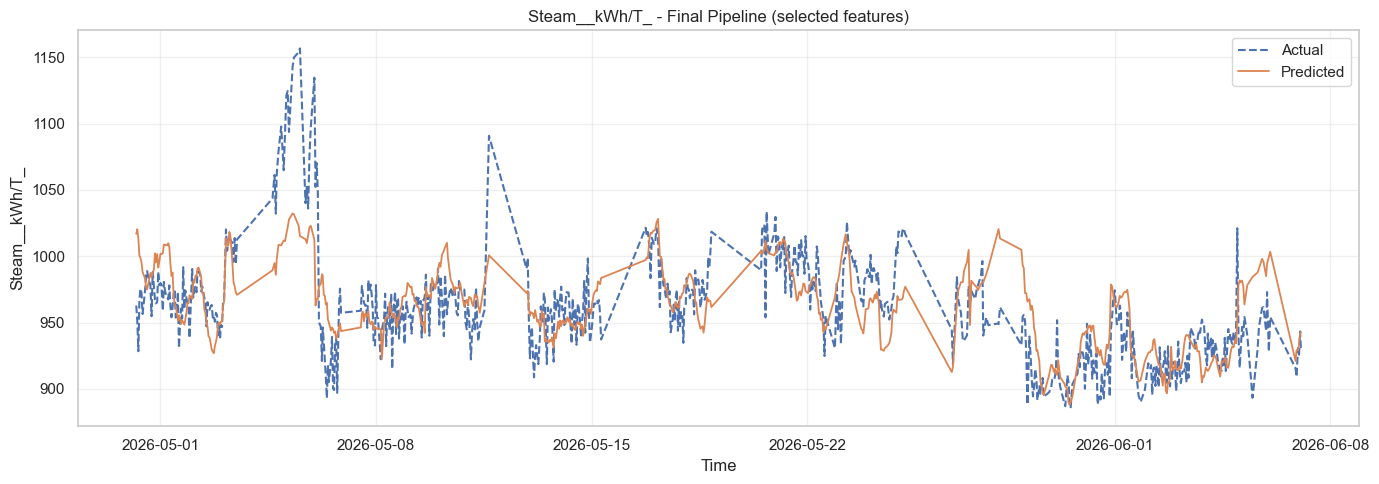

Test RMSE: 29.52, MAE: 21.83, R2: 0.4579


In [10]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_actual.index, y_actual.values, label='Actual', lw=1.5, ls='--')
ax.plot(y_actual.index, y_pred, label='Predicted', lw=1.3)
ax.set_title(f'{Y_COLUMN} - Final Pipeline (selected features)')
ax.set_xlabel('Time')
ax.set_ylabel(Y_COLUMN)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
print(f'Test RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}')

## Mathematical Formulation: Iterative Regression + State Decomposition

The approach below implements a **backfitting** algorithm (Hastie & Tibshirani, 1990), closely related to 
**ECM (Expectation-Conditional Maximization)** for additive models. It decomposes the target into a 
regression component and a latent local-level state.

### Model

$$
y_t = s_t + X_t^\top \beta + \epsilon_t
$$

with a local-level (random walk) state:

$$
s_t = s_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2)
$$

and observation noise $\epsilon_t \sim \mathcal{N}(0, \sigma_\epsilon^2)$.

- $X_t^\top \beta$: contribution explained by process variables (Ridge regression)
- $s_t$: persistent latent drift (unobserved disturbances, slow process changes)
- $\epsilon_t$: observation noise

### Alternating Estimation Scheme

**Iteration 0:** Initialize $\hat{s}_t^{(0)} = 0$.

**General iteration $k$:**

1. **Regression step** â€” fit on the de-stated target:
$$
\hat{\beta}^{(k)} = \arg\min_\beta \sum_t \left( (y_t - \hat{s}_t^{(k)}) - X_t^\top \beta \right)^2 + \lambda \|\beta\|^2
$$

2. **Residual computation** â€” from the *original* target:
$$
r_t^{(k)} = y_t - X_t^\top \hat{\beta}^{(k)}
$$

   Note: $r_t^{(k)} \approx s_t + \epsilon_t$ (contains both state and noise).

3. **State estimation** â€” Kalman smoother separates state from noise:
$$
\hat{s}_t^{(k+1)} = \mathbb{E}\left[ s_t \mid r_{1:T}^{(k)} \right]
$$

The cycle repeats:

$$
\boxed{\hat{s}^{(k)} \rightarrow \hat{\beta}^{(k)} \rightarrow r^{(k)} \rightarrow \hat{s}^{(k+1)}}
$$

### Why not set $\hat{s}_t = r_t$ directly?

Because $r_t = s_t + \epsilon_t$. Assigning the full residual to the state would absorb the noise, 
leading to overfitting. The Kalman smoother optimally separates the persistent component ($s_t$) from 
the transient noise ($\epsilon_t$) by estimating $\sigma_\eta^2 / \sigma_\epsilon^2$ via MLE.

### Connection to standard methods

- **Backfitting** (Hastie & Tibshirani, 1990): alternates between estimating each additive component 
  while holding others fixed. Here the two components are $X\beta$ and $s_t$.
- **ECM** (Meng & Rubin, 1993): a generalization of EM where each M-step is split into conditional 
  maximizations. Here: (1) maximize over $\beta$ given $\hat{s}$, (2) maximize over $s$ given $\hat{\beta}$.
- **Structural Time Series** (Harvey, 1989): the full joint model. Our iterative approach approximates 
  the joint MLE by alternating, which is computationally cheaper and allows using feature selection 
  (CMA-ES) in the regression step.

### Convergence

Each iteration reduces the penalized negative log-likelihood. In practice, 2-3 iterations suffice 
because the level and regression are near-orthogonal (the regression captures fast/correlated variation, 
the level captures slow drift).

## 10. Iterative Backfitting (Regression + State)

In [38]:
from state_estimation import iterative_backfit
from feature_selection import cmaes_feature_selection, fit_all_features

SKIP_FEATURE_SELECTION = False

def run_feature_selection(X_full, y_full, iteration, splines=False):
    if SKIP_FEATURE_SELECTION:
        return fit_all_features(X_full, y_full, cv_splits=outer_cv, splines=splines)
    else:
        return cmaes_feature_selection(
            X_full, y_full,
            k_range=(3, 15),
            fixed_features=fixed_features_resolved,
            feature_groups=feature_groups,
            cv_splits=outer_cv,
            selection='topk',
            max_evals=3000,
            sigma0=1.0,
            seed=42,
            popsize=24,
            penalty_fn=None,
            splines=splines,
            verbose=False,
        )

# Run iterative backfitting
backfit_result = iterative_backfit(
    X=X,
    y=y,
    train_idx=np.arange(split),
    test_idx=np.arange(split, len(X)),
    feature_selection_fn=run_feature_selection,
    n_iterations=20,
    patience=2,
    state_estimator_kwargs={'level': True, 'stochastic_level': True},
    splines=False,
    verbose=True,
)


ITERATION 1/20

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 1):
    Features: 30
    Ridge RMSE: 29.104, R2: 0.4730
    Combined RMSE: 12.552, R2: 0.9020
    Level scale: 10.7967
    *** New best ***

ITERATION 2/20

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 2):
    Features: 28
    Ridge RMSE: 28.978, R2: 0.4775
    Combined RMSE: 12.780, R2: 0.8984
    Level scale: 10.5061
    *** New best ***

ITERATION 3/20

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 3):
    Features: 30
    Ridge RMSE: 28.859, R2: 0.4818
    Combined RMSE: 12.702, R2: 0.8996
    Level scale: 10.2609
    *** New best ***

ITERATION 4/20

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 4):
    Features: 30
   

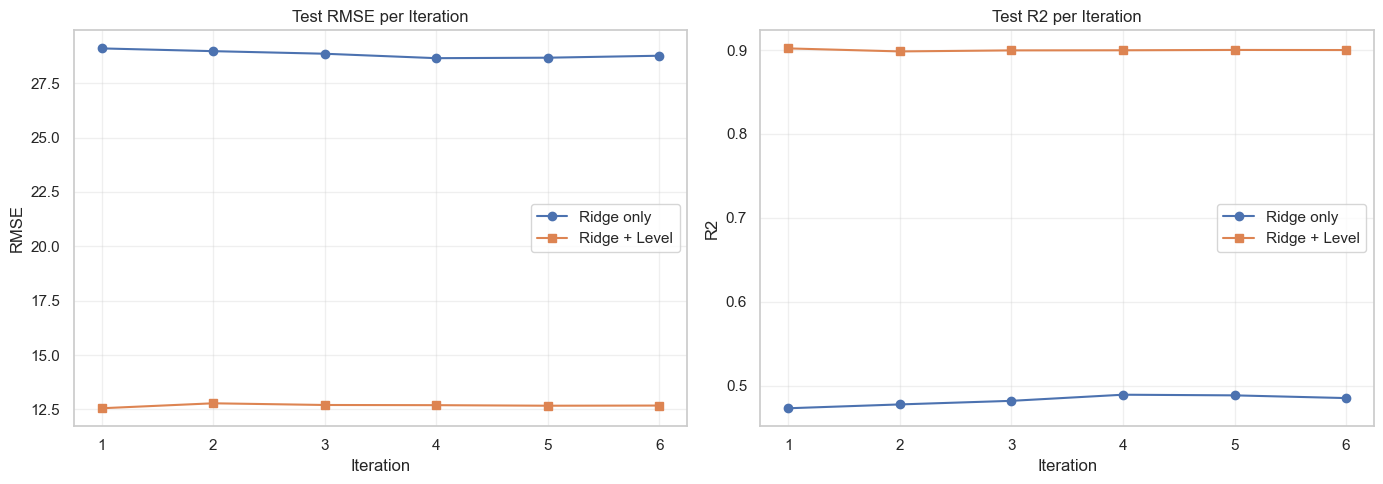

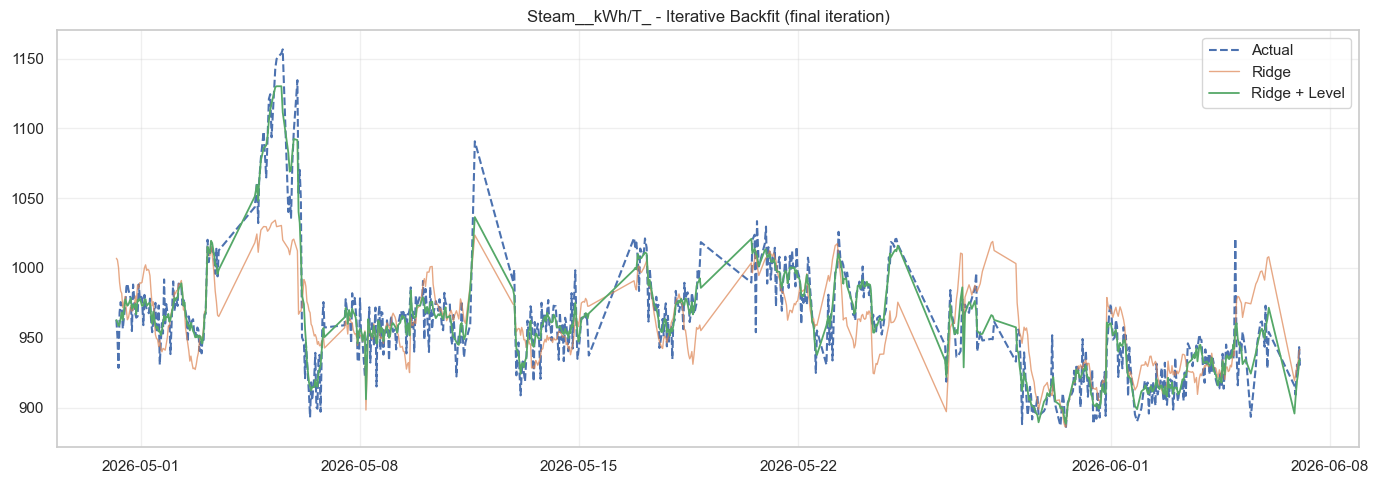

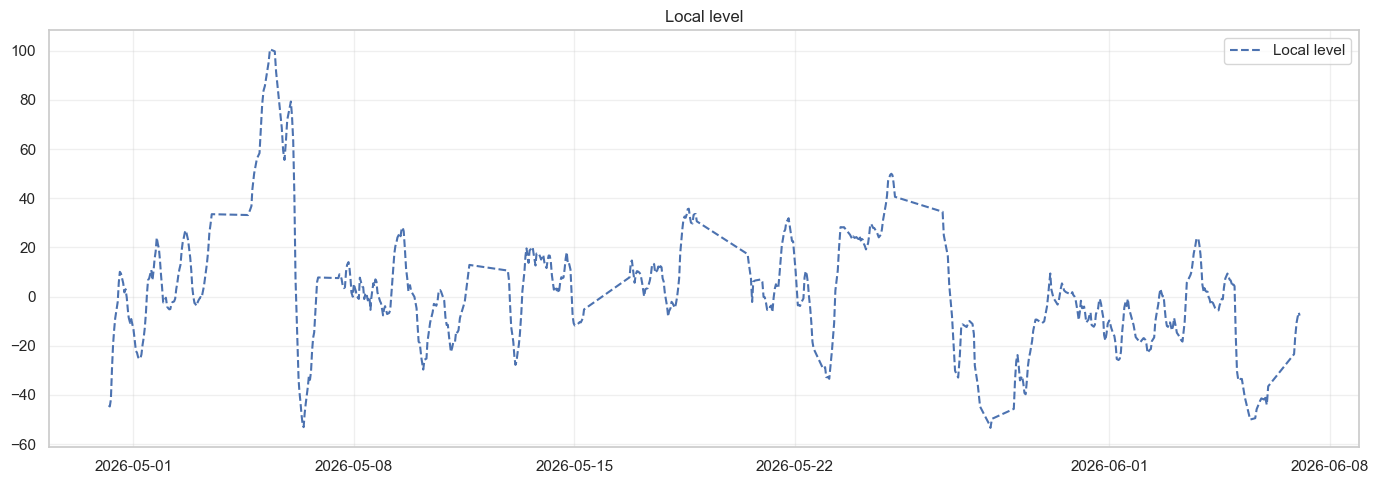

In [40]:
# Plot convergence across iterations
history = backfit_result['iteration_history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = [h['iteration'] for h in history]
axes[0].plot(iters, [h['rmse_ridge'] for h in history], 'o-', label='Ridge only')
axes[0].plot(iters, [h['rmse_combined'] for h in history], 's-', label='Ridge + Level')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Test RMSE per Iteration')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(iters, [h['r2_ridge'] for h in history], 'o-', label='Ridge only')
axes[1].plot(iters, [h['r2_combined'] for h in history], 's-', label='Ridge + Level')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('R2')
axes[1].set_title('Test R2 per Iteration')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final prediction plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yte.index, yte.values, label='Actual', lw=1.5, ls='--')
ax.plot(backfit_result['y_test_pred'].index, backfit_result['y_test_pred'].values,
        label='Ridge', lw=1.0, alpha=0.7)
ax.plot(backfit_result['y_test_combined'].index, backfit_result['y_test_combined'].values,
        label='Ridge + Level', lw=1.3)
ax.set_title(f'{Y_COLUMN} - Iterative Backfit (final iteration)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Final prediction plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(backfit_result['y_test_pred'].index, backfit_result['level_test'], label='Local level', lw=1.5, ls='--')
ax.set_title(f'Local level')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Evaluate Best Iteration on Test

In [41]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Use the estimator directly from the best backfit iteration
est = backfit_result['feature_selection_result'].final_estimator
features = backfit_result['selected_features']

# Predict on already-transformed test data
y_test_pred = est.predict(Xte[features].values)
y_test_actual = yte.values

# Metrics (Ridge only)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
mae = mean_absolute_error(y_test_actual, y_test_pred)
r2 = r2_score(y_test_actual, y_test_pred)
print(f'Ridge only:  RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}')

# Metrics (Ridge + Level)
y_test_combined = backfit_result['y_test_combined'].values
rmse_c = np.sqrt(mean_squared_error(y_test_actual, y_test_combined))
mae_c = mean_absolute_error(y_test_actual, y_test_combined)
r2_c = r2_score(y_test_actual, y_test_combined)
print(f'Ridge+Level: RMSE={rmse_c:.2f}, MAE={mae_c:.2f}, R2={r2_c:.4f}')

Ridge only:  RMSE=28.66, MAE=21.32, R2=0.4891
Ridge+Level: RMSE=12.69, MAE=9.23, R2=0.8997


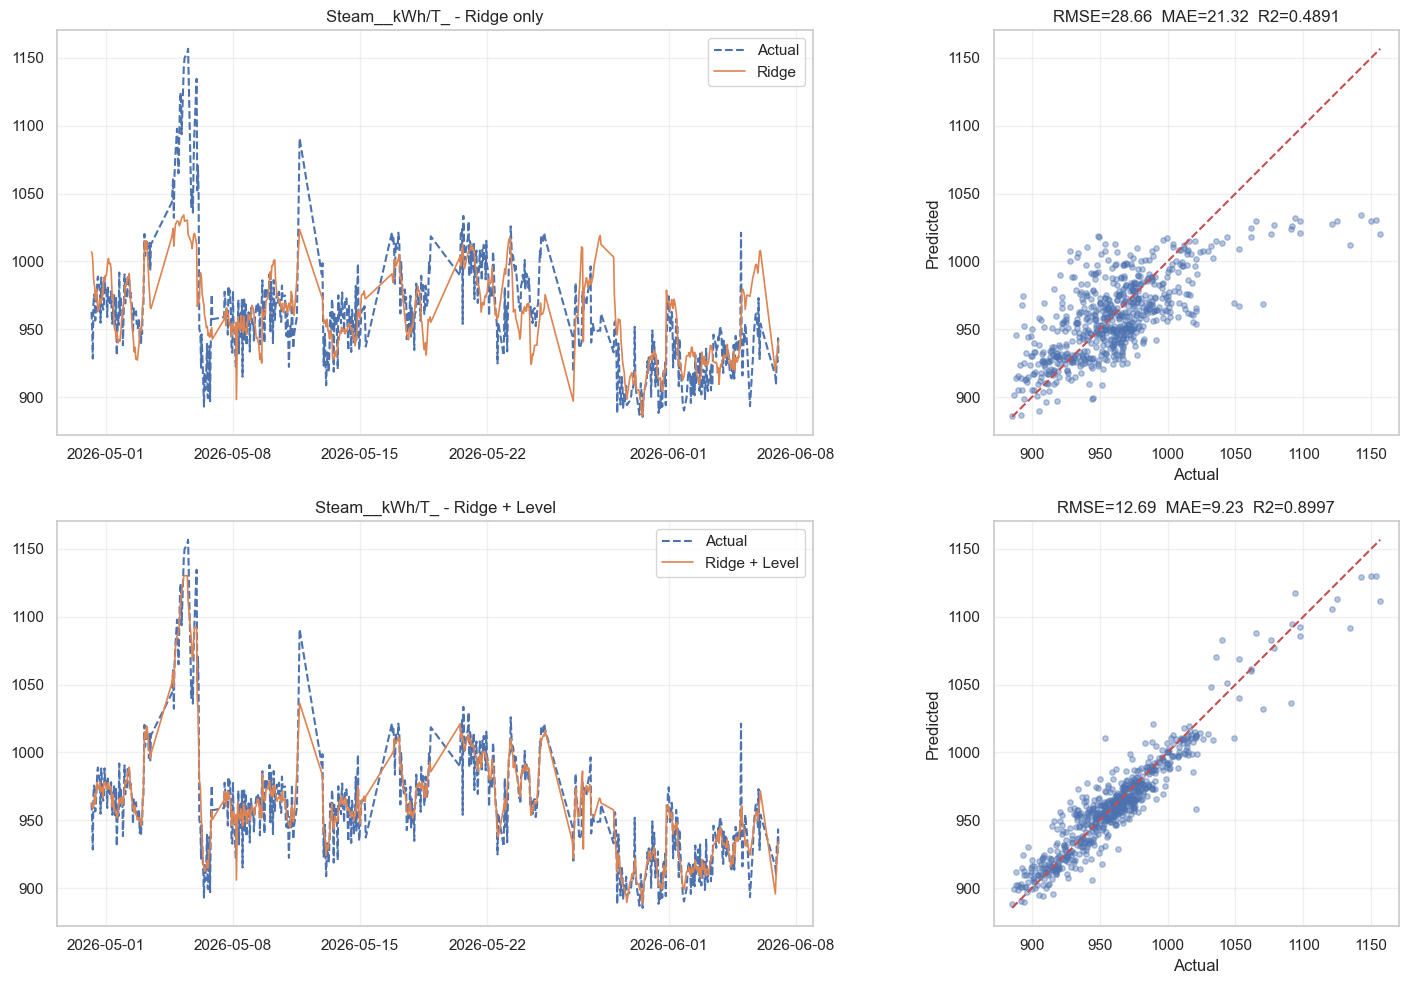

In [42]:
# Time series and scatter plots
test_index = yte.index

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top row: Ridge only
axes[0, 0].plot(test_index, y_test_actual, label='Actual', lw=1.5, ls='--')
axes[0, 0].plot(test_index, y_test_pred, label='Ridge', lw=1.2)
axes[0, 0].set_title(f'{Y_COLUMN} - Ridge only')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(y_test_actual, y_test_pred, alpha=0.4, s=15)
lims = [min(y_test_actual.min(), y_test_pred.min()),
        max(y_test_actual.max(), y_test_pred.max())]
axes[0, 1].plot(lims, lims, 'r--', lw=1.5)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.4f}')
axes[0, 1].set_aspect('equal', adjustable='box')
axes[0, 1].grid(alpha=0.3)

# Bottom row: Ridge + Level
axes[1, 0].plot(test_index, y_test_actual, label='Actual', lw=1.5, ls='--')
axes[1, 0].plot(test_index, y_test_combined, label='Ridge + Level', lw=1.2)
axes[1, 0].set_title(f'{Y_COLUMN} - Ridge + Level')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(y_test_actual, y_test_combined, alpha=0.4, s=15)
lims_c = [min(y_test_actual.min(), y_test_combined.min()),
          max(y_test_actual.max(), y_test_combined.max())]
axes[1, 1].plot(lims_c, lims_c, 'r--', lw=1.5)
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title(f'RMSE={rmse_c:.2f}  MAE={mae_c:.2f}  R2={r2_c:.4f}')
axes[1, 1].set_aspect('equal', adjustable='box')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. RealMLP on Drift-Adjusted Target (all features)

In [43]:
from pytabkit import RealMLP_TD_Regressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Use the best level from backfitting to adjust the target
level_train = backfit_result['level_train']
level_test = backfit_result['level_test']
y_adjusted_train = ytr.values - level_train.values

# Train RealMLP on ALL transformed features with drift-adjusted target
all_features = list(X.columns)
X_train_all = Xtr[all_features].values
X_test_all = Xte[all_features].values

mlp = RealMLP_TD_Regressor(n_epochs=256*4, random_state=42)
mlp.fit(X_train_all, y_adjusted_train)

# Predict (regression only)
y_mlp_pred = mlp.predict(X_test_all).ravel()

# Combined: MLP + level
y_mlp_combined = y_mlp_pred + level_test.values

# Metrics
y_actual = yte.values
rmse_mlp = np.sqrt(mean_squared_error(y_actual, y_mlp_pred))
r2_mlp = r2_score(y_actual, y_mlp_pred)
mae_mlp = mean_absolute_error(y_actual, y_mlp_pred)
rmse_mlp_c = np.sqrt(mean_squared_error(y_actual, y_mlp_combined))
r2_mlp_c = r2_score(y_actual, y_mlp_combined)
mae_mlp_c = mean_absolute_error(y_actual, y_mlp_combined)

print(f'RealMLP only:  RMSE={rmse_mlp:.2f}, MAE={mae_mlp:.2f}, R2={r2_mlp:.4f}')
print(f'RealMLP+Level: RMSE={rmse_mlp_c:.2f}, MAE={mae_mlp_c:.2f}, R2={r2_mlp_c:.4f}')

c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1024` reached.
c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and wil

RealMLP only:  RMSE=34.70, MAE=27.01, R2=0.2510
RealMLP+Level: RMSE=24.77, MAE=21.20, R2=0.6183


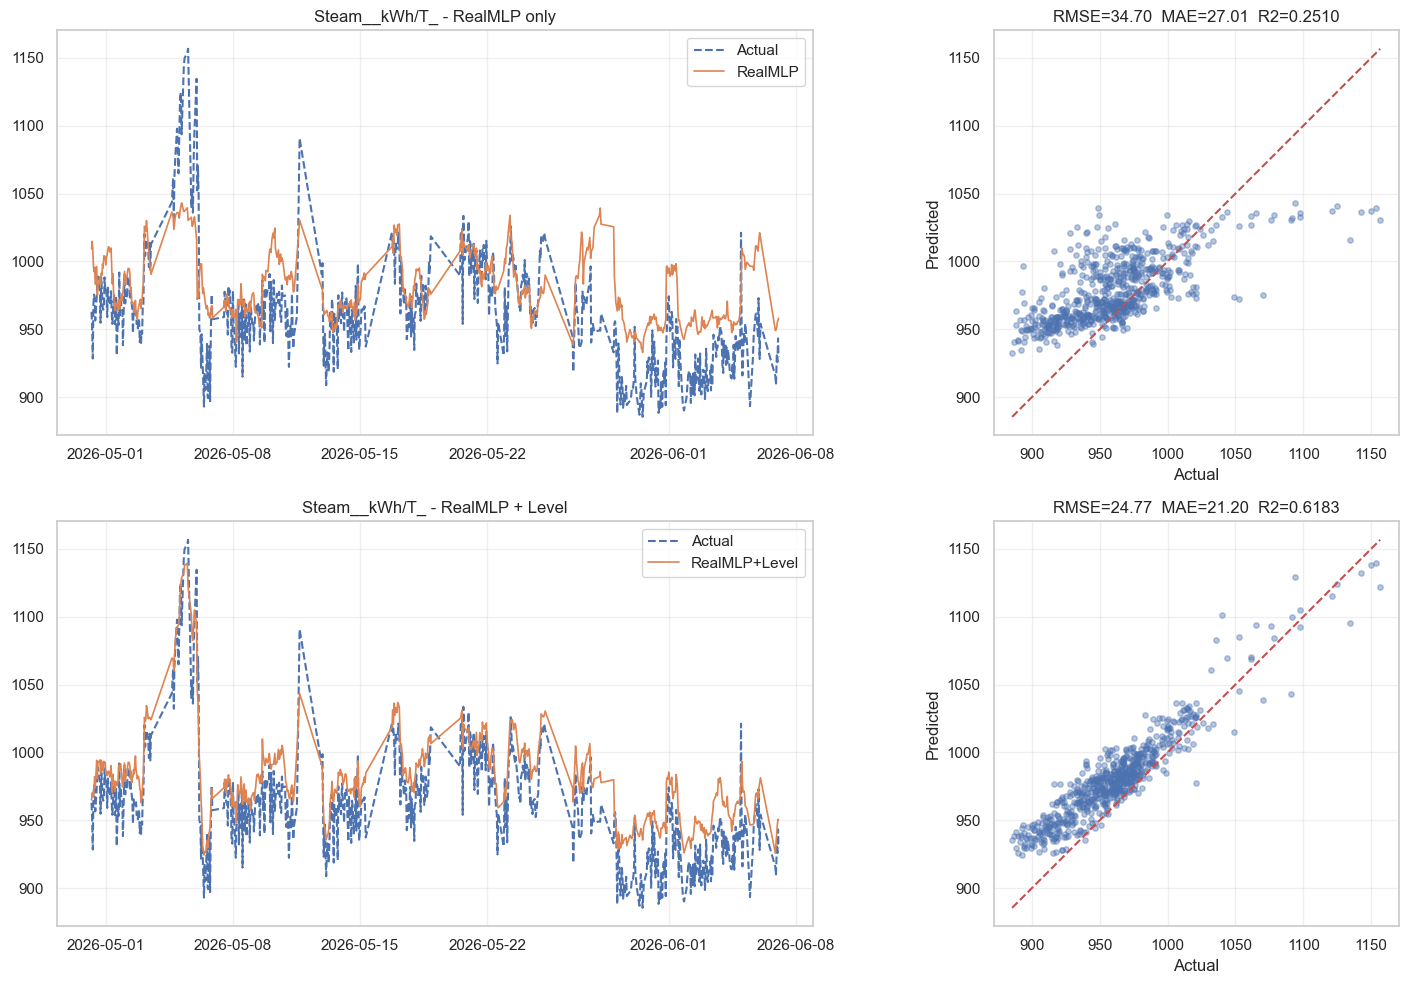

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
test_index = yte.index

# Top: RealMLP only
axes[0,0].plot(test_index, y_actual, label='Actual', lw=1.5, ls='--')
axes[0,0].plot(test_index, y_mlp_pred, label='RealMLP', lw=1.2)
axes[0,0].set_title(f'{Y_COLUMN} - RealMLP only')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].scatter(y_actual, y_mlp_pred, alpha=0.4, s=15)
lims=[min(y_actual.min(),y_mlp_pred.min()),max(y_actual.max(),y_mlp_pred.max())]
axes[0,1].plot(lims,lims,'r--',lw=1.5)
axes[0,1].set_xlabel('Actual'); axes[0,1].set_ylabel('Predicted')
axes[0,1].set_title(f'RMSE={rmse_mlp:.2f}  MAE={mae_mlp:.2f}  R2={r2_mlp:.4f}')
axes[0,1].set_aspect('equal',adjustable='box'); axes[0,1].grid(alpha=0.3)

# Bottom: RealMLP + Level
axes[1,0].plot(test_index, y_actual, label='Actual', lw=1.5, ls='--')
axes[1,0].plot(test_index, y_mlp_combined, label='RealMLP+Level', lw=1.2)
axes[1,0].set_title(f'{Y_COLUMN} - RealMLP + Level')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].scatter(y_actual, y_mlp_combined, alpha=0.4, s=15)
lims_c=[min(y_actual.min(),y_mlp_combined.min()),max(y_actual.max(),y_mlp_combined.max())]
axes[1,1].plot(lims_c,lims_c,'r--',lw=1.5)
axes[1,1].set_xlabel('Actual'); axes[1,1].set_ylabel('Predicted')
axes[1,1].set_title(f'RMSE={rmse_mlp_c:.2f}  MAE={mae_mlp_c:.2f}  R2={r2_mlp_c:.4f}')
axes[1,1].set_aspect('equal',adjustable='box'); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. RealMLP Hyperparameter Tuning + Final Fit

In [45]:
from pytabkit import RealMLP_HPO_Regressor, RealMLP_TD_Regressor

# Chronological train/val split for HPO (last 20% of training as validation)
level_train = backfit_result['level_train']
y_adjusted_train = ytr.values - level_train.values

val_size = int(len(Xtr) * 0.2)
X_train_mlp = Xtr.iloc[:-val_size].values
y_train_mlp = y_adjusted_train[:-val_size]
X_val_mlp = Xtr.iloc[-val_size:].values
y_val_mlp = y_adjusted_train[-val_size:]

# HPO: search over configurations
reg_hpo = RealMLP_HPO_Regressor(
    n_hyperopt_steps=30,
    hpo_space_name='tabarena-new',
    val_metric_name='rmse',
    n_refit=0,
    random_state=42,
    time_limit_s=3 * 60 * 60,
)
reg_hpo.fit(X_train_mlp, y_train_mlp, X_val_mlp, y_val_mlp)

print('HPO complete.')

c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, 

HPO complete.


In [46]:
# Extract best hyperparameters
allowed_params = {
    'hidden_sizes', 'lr', 'batch_size', 'n_epochs',
    'weight_decay', 'dropout', 'act', 'num_emb_type',
    'num_emb_dim', 'plr_sigma', 'ls_eps', 'tfms',
    'p_drop_sched', 'wd_sched',
}

final_params = {
    key: value
    for key, value in reg_hpo.fit_params_['sub_fit_params'].items()
    if key in allowed_params
}

print('Best params:')
for k, v in final_params.items():
    print(f'  {k}: {v}')

Best params:
  hidden_sizes: rectangular
  act: mish
  wd_sched: flat_cos
  p_drop_sched: flat_cos
  tfms: ['one_hot', 'median_center', 'robust_scale', 'smooth_clip', 'embedding']
  num_emb_type: pbld
  plr_sigma: 0.017600470431067487
  lr: 0.2640594536743722
  n_epochs: 256
  ls_eps: 0.005337848011449801


In [47]:
# Final model with best params, refitted with ensembling
final_reg = RealMLP_TD_Regressor(
    **final_params,
    n_refit=10,
    use_early_stopping=True,
    val_metric_name='rmse',
    random_state=42,
    verbosity=2,
)
final_reg.fit(X_train_mlp, y_train_mlp, X_val_mlp, y_val_mlp)

# Predict on test
y_mlp_pred = final_reg.predict(Xte.values).ravel()
y_mlp_combined = y_mlp_pred + backfit_result['level_test'].values

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_actual = yte.values
rmse_mlp = np.sqrt(mean_squared_error(y_actual, y_mlp_pred))
r2_mlp = r2_score(y_actual, y_mlp_pred)
mae_mlp = mean_absolute_error(y_actual, y_mlp_pred)
rmse_mlp_c = np.sqrt(mean_squared_error(y_actual, y_mlp_combined))
r2_mlp_c = r2_score(y_actual, y_mlp_combined)
mae_mlp_c = mean_absolute_error(y_actual, y_mlp_combined)

print(f'RealMLP (tuned) only:  RMSE={rmse_mlp:.2f}, MAE={mae_mlp:.2f}, R2={r2_mlp:.4f}')
print(f'RealMLP (tuned)+Level: RMSE={rmse_mlp_c:.2f}, MAE={mae_mlp_c:.2f}, R2={r2_mlp_c:.4f}')

c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Columns classified as continuous: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
Columns classified as categorical: []


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/256: val rmse = 35.202904
Epoch 2/256: val rmse = 19.545786
Epoch 3/256: val rmse = 21.578915
Epoch 4/256: val rmse = 21.075415
Epoch 5/256: val rmse = 15.085520
Epoch 6/256: val rmse = 13.863475
Epoch 7/256: val rmse = 17.437336
Epoch 8/256: val rmse = 17.365036
Epoch 9/256: val rmse = 15.241574
Epoch 10/256: val rmse = 16.301371
Epoch 11/256: val rmse = 15.106474
Epoch 12/256: val rmse = 12.844905
Epoch 13/256: val rmse = 17.900295
Epoch 14/256: val rmse = 14.444976
Epoch 15/256: val rmse = 16.379570
Epoch 16/256: val rmse = 14.258475
Epoch 17/256: val rmse = 14.680471
Epoch 18/256: val rmse = 15.082279
Epoch 19/256: val rmse = 14.398623
Epoch 20/256: val rmse = 16.259275
Epoch 21/256: val rmse = 14.180758
Epoch 22/256: val rmse = 17.497509
Epoch 23/256: val rmse = 21.838009
Epoch 24/256: val rmse = 17.821821
Epoch 25/256: val rmse = 17.102222
Epoch 26/256: val rmse = 17.317896
Epoch 27/256: val rmse = 16.917017
Epoch 28/256: val rmse = 21.350687
Epoch 29/256: val rmse = 17.4

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Refit: stop_epochs=[[{'rmse': 12}, {'rmse': 12}, {'rmse': 12}, {'rmse': 12}, {'rmse': 12}, {'rmse': 12}, {'rmse': 12}, {'rmse': 12}, {'rmse': 12}, {'rmse': 12}]]
Refit Epoch 0/12
Refit Epoch 1/12
Refit Epoch 2/12
Refit Epoch 3/12
Refit Epoch 4/12
Refit Epoch 5/12
Refit Epoch 6/12
Refit Epoch 7/12
Refit Epoch 8/12
Refit Epoch 9/12
Refit Epoch 10/12
Refit Epoch 11/12
Refit Epoch 12/12


c:\workspace\costimiser\training\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


RealMLP (tuned) only:  RMSE=32.43, MAE=24.86, R2=0.3457
RealMLP (tuned)+Level: RMSE=20.90, MAE=16.99, R2=0.7282


In [50]:
Xtr

,ambient_temp_C,Draw_PS-PD1,Moisture_out_of_PreDryer,Draw_WS-PS,PickUp_Tension,Dewatering_top_wire_suction_box_zone_2,White_water_temperature,Top_wire_tenstion,Jet/wire_ratio,Top_Felt_Tension,...,linepressure_1,fabric_tension_1,gas_decu_1,gas_decu_2,gas_decu_3,grammage_90,grammage_100,grammage_110,grammage_115,grammage_120
Wedge_Time,,,,,,,,,,,,,,,,,,,,,
2025-11-16 10:38:30,1.140587,0.850462,-0.013184,0.566921,-0.169528,0.529618,0.062881,1.210782,0.733439,0.217943,...,1.764218,0.759112,2.276399,0.694606,0.210830,0.0,0.0,0.0,1.0,0.0
2025-11-16 11:27:30,1.140587,0.858292,1.041221,0.059075,-0.118929,0.762971,0.080160,0.931956,0.734636,0.091848,...,0.637231,0.962157,1.808992,0.383836,-0.196672,0.0,0.0,0.0,1.0,0.0
2025-11-16 12:16:30,1.296767,0.858835,0.036008,-0.072166,-0.193474,0.668408,0.038558,-1.921805,0.738829,0.158949,...,-0.352147,0.985113,1.623643,0.443892,-0.641269,0.0,0.0,0.0,1.0,0.0
2025-11-16 13:05:30,1.491991,0.858835,-0.631108,0.703869,-0.149614,0.811617,0.211202,1.309353,0.730210,0.230438,...,-0.935281,0.993956,1.596798,0.329625,-0.750864,0.0,0.0,0.0,1.0,0.0
2025-11-16 13:55:30,1.570081,0.854842,0.055554,-0.009398,-0.178128,0.465683,0.183012,1.577400,0.733819,0.118483,...,-1.810786,1.076374,1.858615,0.483636,-0.599511,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-30 01:00:30,0.340166,-0.118061,-1.151213,0.344382,-0.104206,-1.385283,0.550018,-0.770340,-0.106850,0.747414,...,-0.558492,0.389817,0.047786,-0.179704,-1.223924,0.0,0.0,0.0,0.0,1.0
2026-04-30 01:49:30,0.066851,-0.122053,-0.140379,0.344382,-0.112416,-1.264288,0.463366,-1.144674,-0.099530,0.700370,...,-0.395807,0.443933,0.090946,-0.170288,-1.665462,0.0,0.0,0.0,0.0,1.0
2026-04-30 02:38:30,-0.284553,-0.118138,0.055591,0.835110,-0.137371,-1.552542,0.355505,-1.324972,-0.105911,0.688071,...,-0.462585,0.388664,0.574428,-0.378312,-1.483277,0.0,0.0,0.0,0.0,1.0


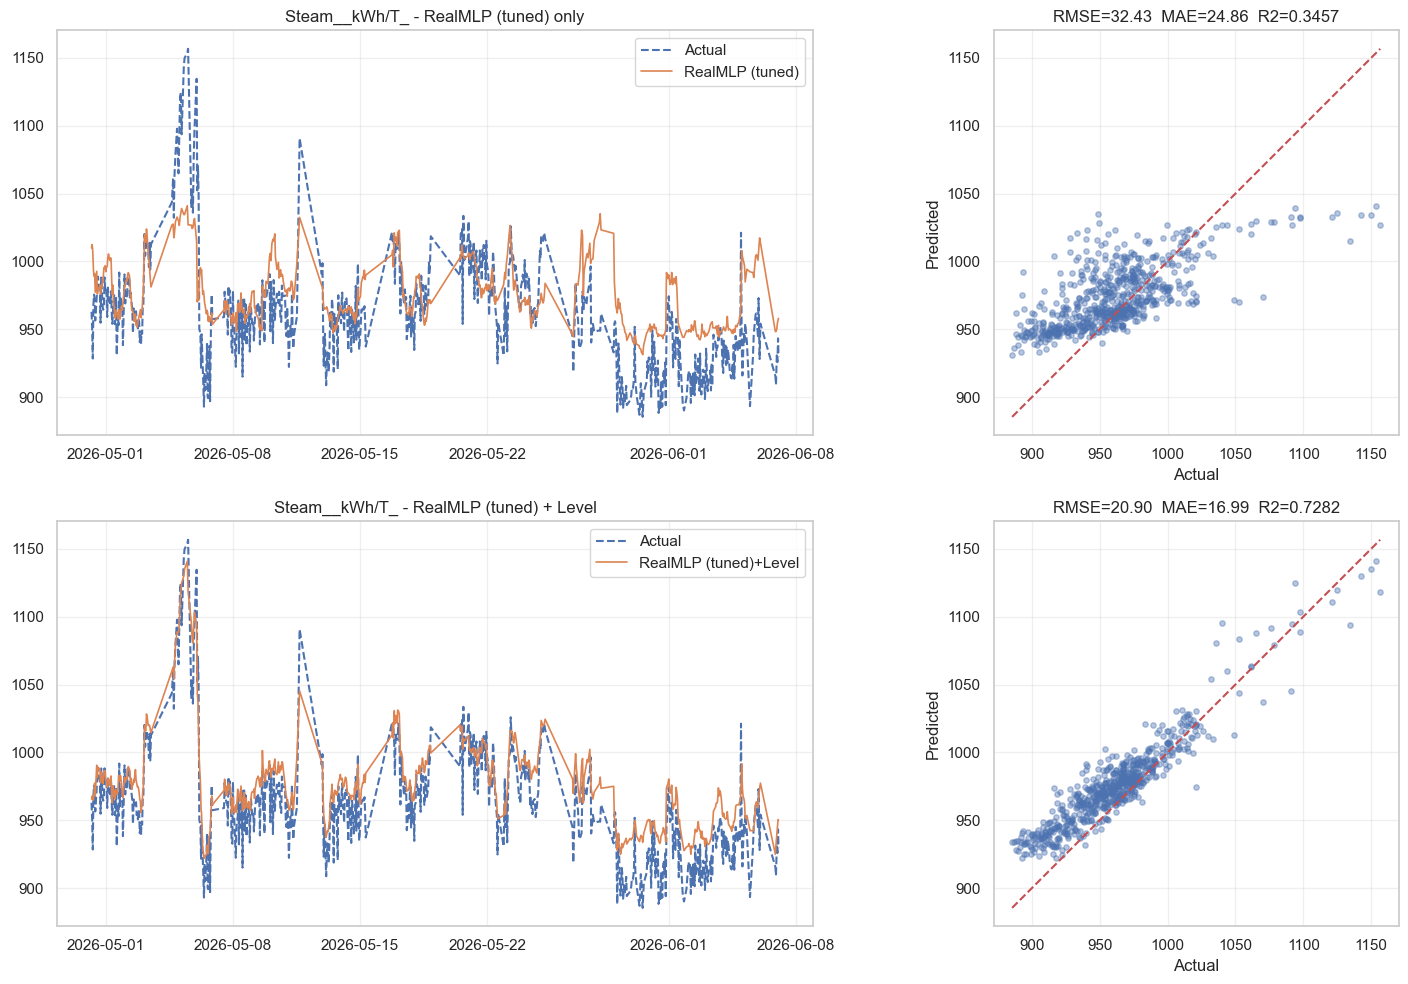

In [48]:
# Plot tuned RealMLP results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
test_index = yte.index

# Top: RealMLP only
axes[0,0].plot(test_index, y_actual, label='Actual', lw=1.5, ls='--')
axes[0,0].plot(test_index, y_mlp_pred, label='RealMLP (tuned)', lw=1.2)
axes[0,0].set_title(f'{Y_COLUMN} - RealMLP (tuned) only')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].scatter(y_actual, y_mlp_pred, alpha=0.4, s=15)
lims=[min(y_actual.min(),y_mlp_pred.min()),max(y_actual.max(),y_mlp_pred.max())]
axes[0,1].plot(lims,lims,'r--',lw=1.5)
axes[0,1].set_xlabel('Actual'); axes[0,1].set_ylabel('Predicted')
axes[0,1].set_title(f'RMSE={rmse_mlp:.2f}  MAE={mae_mlp:.2f}  R2={r2_mlp:.4f}')
axes[0,1].set_aspect('equal',adjustable='box'); axes[0,1].grid(alpha=0.3)

# Bottom: RealMLP + Level
axes[1,0].plot(test_index, y_actual, label='Actual', lw=1.5, ls='--')
axes[1,0].plot(test_index, y_mlp_combined, label='RealMLP (tuned)+Level', lw=1.2)
axes[1,0].set_title(f'{Y_COLUMN} - RealMLP (tuned) + Level')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].scatter(y_actual, y_mlp_combined, alpha=0.4, s=15)
lims_c=[min(y_actual.min(),y_mlp_combined.min()),max(y_actual.max(),y_mlp_combined.max())]
axes[1,1].plot(lims_c,lims_c,'r--',lw=1.5)
axes[1,1].set_xlabel('Actual'); axes[1,1].set_ylabel('Predicted')
axes[1,1].set_title(f'RMSE={rmse_mlp_c:.2f}  MAE={mae_mlp_c:.2f}  R2={r2_mlp_c:.4f}')
axes[1,1].set_aspect('equal',adjustable='box'); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Production Model: Preprocessing + Ridge (fitted on all data)

In [49]:
from preprocessing import build_final_pipeline

# Build complete pipeline: raw data -> FeatureCreator -> PLS -> Filter -> Scaler -> Ridge
# Uses only the selected features from backfitting
production_pipeline, production_feat_list = build_final_pipeline(
    selected_features=backfit_result['selected_features'],
    prep_pip=prep_pip,
    created_vars=created_vars,
    ridge_alpha=backfit_result['feature_selection_result'].best_alpha,
    apply_ewm=APPLY_EWM_FILTER,
)

# Fit on ALL data (train + test) with level-adjusted target
# Concatenate train and test levels
level_full = pd.concat([backfit_result['level_train'], backfit_result['level_test']])
y_adjusted_full = turnup_ts[Y_COLUMN].iloc[:len(level_full)] - level_full.values

production_pipeline.fit(
    turnup_ts[production_feat_list].iloc[:len(level_full)],
    y_adjusted_full,
)

print(f'Production pipeline fitted on {len(level_full)} samples.')
print(f'Steps: {[name for name, _ in production_pipeline.steps]}')
print(f'Input columns ({len(production_feat_list)}): {production_feat_list}')
print(f'Ridge alpha: {backfit_result["feature_selection_result"].best_alpha:.2f}')

Production pipeline fitted on 3320 samples.
Steps: ['feat', 'exha_mois', 'inlet_temp', 'linepressure', 'fabric_tension', 'gas_decu', 'filter', 'scaler_encoder', 'ridge']
Input columns (43): ['ambient_temp_C', 'White_water_temperature', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Steam_temperature_for_PM', 'Dewatering_Shoe_press', 'Uhle_box_1_flow___l/min_', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG2_Ventilator_Revolution_Output', 'retention', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/T_', 'grammage', 'DG1_Moisture_content_Outlet_Air', 'DG2_Moisture_content_Outlet_Air', 'DG4_Moisture_content_Outlet_Air', 'DG5_Moisture_content_Outlet_Air', 'DG1_temperature_Inlet_Air', 'DG2_temperature_Inlet_Air', 'DG3_temperature_Inlet_Air', 'DG4_Temperature_Inlet_Air', 'DG5_Temperature_Inlet_Air', 'Linepressure_1st_press_FS__bar_', 'Linepressure_2nd_press_FS__bar_', 'Linepressure_1

In [ ]:
import cloudpickle

# Save the production model
model_artifact = {
    'pipeline': production_pipeline,
    'feat_list': production_feat_list,
    'selected_features': backfit_result['selected_features'],
    'state_estimator': backfit_result['state_estimator'],
    'level_scale': backfit_result['iteration_history'][-1]['level_scale'],
    'obs_noise_scale': backfit_result['iteration_history'][-1]['obs_noise_scale'],
    'target_column': Y_COLUMN,
}

with open(f'model_{Y_COLUMN.replace("/","_")}.pkl', 'wb') as f:
    cloudpickle.dump(model_artifact, f)

print(f'Model saved.')
print(f'Usage:')
print(f'  y_regression = pipeline.predict(new_data[feat_list])')
print(f'  y_full = y_regression + state_estimator.update(residuals).level.iloc[-n:]')